# Calibrating a Function Generator 
#### Data Visualization and Analysis

In [46]:
import numpy as np
import matplotlib.pyplot as plt

##### Plot Styling Function

In [75]:
def plot_fft_stems(freq_vec, mag_vec, title="FFT Spectrum", x_max=None):
    """
    Plots pre-computed FFT data in an oscilloscope style (Green stems / Black background).
    
    Args:
        freq_vec (np.array): 1D array of pre-calculated frequency values (Hz).
        mag_vec (np.array): 1D array of pre-calculated magnitude values (dB or Linear).
        title (str): Title for the top of the plot.
        x_max (float): Optional limit for the x-axis (Frequency).
    """
    # 1. Determine the dynamic baseline (noise floor)
    bottom_val = np.min(mag_vec)

    # 2. Setup the Dark Mode figure and axis
    plt.figure(figsize=(12, 6), facecolor='black')
    ax = plt.gca()
    ax.set_facecolor('black')

    # 3. Create the Stem Plot
    # bottom=bottom_val ensures stems grow UP from the noise floor
    markerline, stemlines, baseline = plt.stem(freq_vec, mag_vec, bottom=bottom_val)

    # 4. Oscilloscope Styling (Matrix Green)
    plt.setp(stemlines, 'color', '#00FF41', 'linewidth', 1) 
    plt.setp(markerline, 'color', '#00FF41', 'markersize', 3, 'alpha', 0.8)
    plt.setp(baseline, 'visible', False) # Hide the baseline for a cleaner scope look

    # 5. Format labels, grid, and ticks for Dark Mode
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    plt.grid(True, linestyle='--', color='gray', alpha=0.3)

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel("Frequency (Hz)", fontweight='bold')
    plt.ylabel("Magnitude", fontweight='bold')
    
    # 6. Dynamic X-Axis Scaling
    if x_max:
        plt.xlim(0, x_max)
    else:
        plt.xlim(0, np.max(freq_vec))
        
    # Add a bit of headroom on the Y-axis
    plt.ylim(bottom_val, np.max(mag_vec) + 5)

    plt.tight_layout()
    plt.show()



#### Plotting Signals from Function Generator

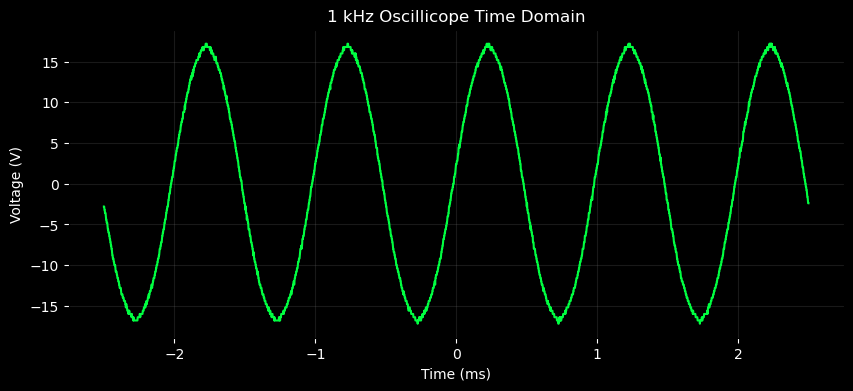

In [76]:
# Load Time Domain data (1k-time.csv)
# Column 3 = Time, Column 4 = Voltage
t_vec = np.genfromtxt('1k-time.csv', delimiter=',', usecols=3)
v_vec = np.genfromtxt('1k-time.csv', delimiter=',', usecols=4)

plt.figure(figsize=(10, 4), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Plotting the 1D vectors
plt.plot(t_vec * 1000, v_vec, color='#00FF41', linewidth=1.5)

# Styling
plt.title("1 kHz Oscillicope Time Domain", color='white')
plt.xlabel("Time (ms)", color='white')
plt.ylabel("Voltage (V)", color='white')
plt.tick_params(colors='white')
plt.grid(True, alpha=0.2, color='gray')
plt.show()

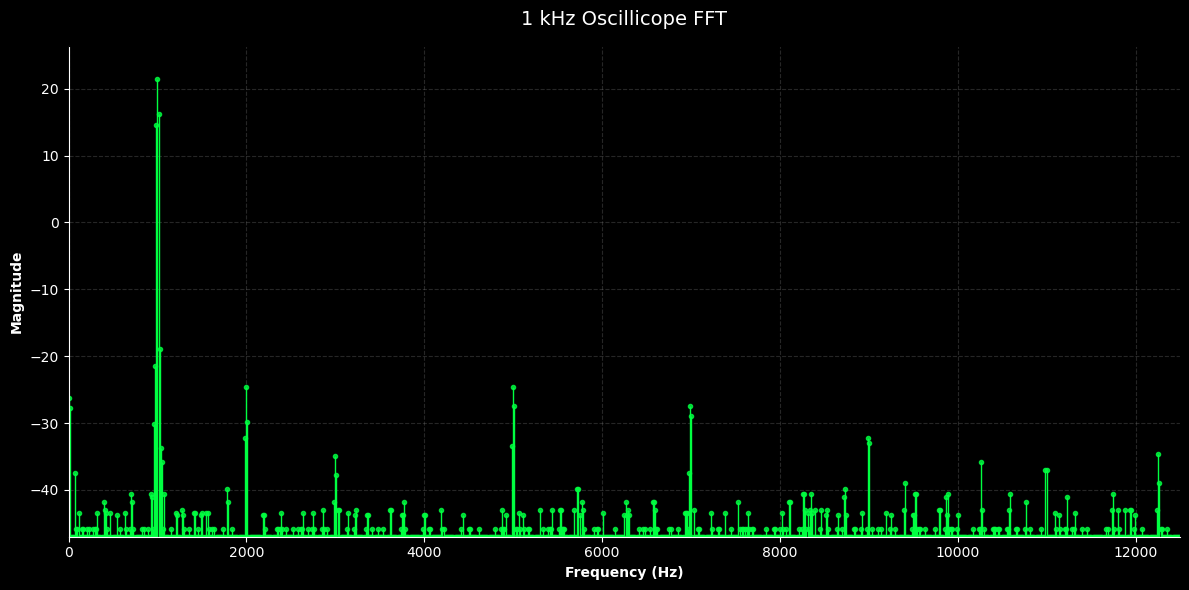

In [77]:
# --- Example Usage ---
freqs = np.genfromtxt('1k-fft.csv', delimiter=',', usecols=3)
mags = np.genfromtxt('1k-fft.csv', delimiter=',', usecols=4)

# Call the function with x_max set to 12500
plot_fft_stems(freqs, mags, title="1 kHz Oscillicope FFT", x_max=12500)

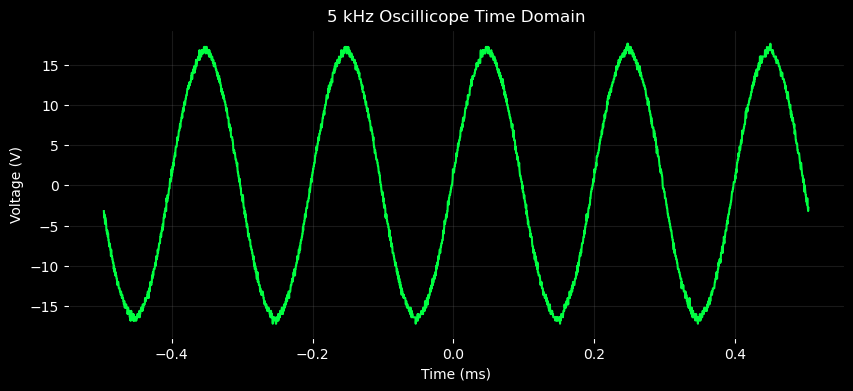

In [79]:
# Load Time Domain data (1k-time.csv)
# Column 3 = Time, Column 4 = Voltage
t_vec = np.genfromtxt('5k-time.csv', delimiter=',', usecols=3)
v_vec = np.genfromtxt('5k-time.csv', delimiter=',', usecols=4)

plt.figure(figsize=(10, 4), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Plotting the 1D vectors
plt.plot(t_vec * 1000, v_vec, color='#00FF41', linewidth=1.5)

# Styling
plt.title("5 kHz Oscillicope Time Domain", color='white')
plt.xlabel("Time (ms)", color='white')
plt.ylabel("Voltage (V)", color='white')
plt.tick_params(colors='white')
plt.grid(True, alpha=0.2, color='gray')
plt.show()

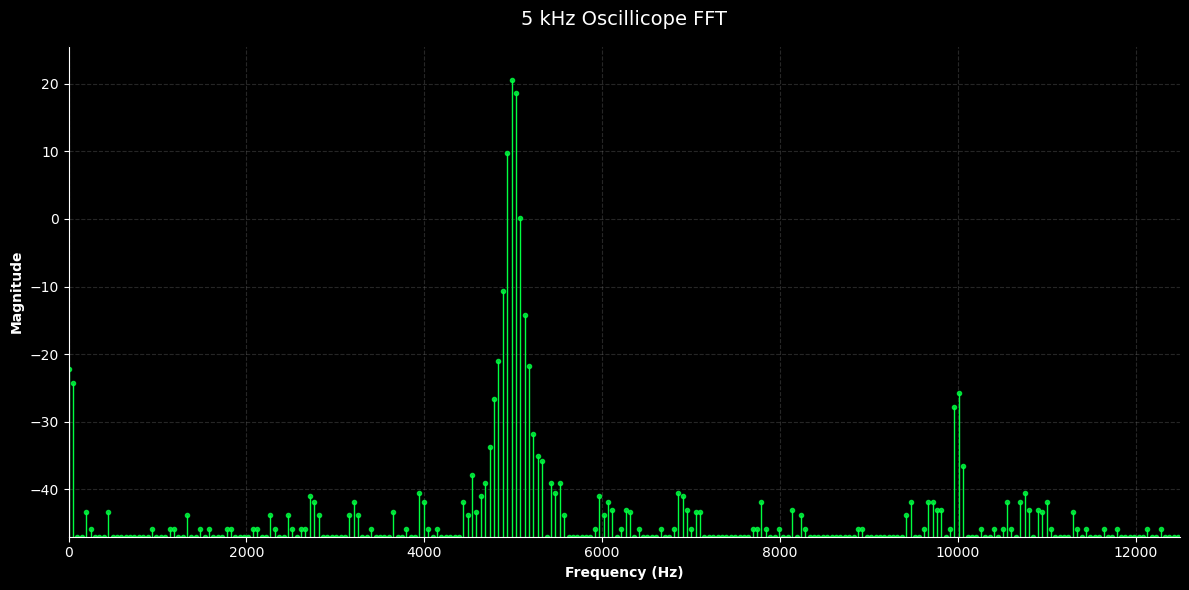

In [80]:
# --- Example Usage ---
freqs = np.genfromtxt('5k-fft.csv', delimiter=',', usecols=3)
mags = np.genfromtxt('5k-fft.csv', delimiter=',', usecols=4)

# Call the function with x_max set to 12500
plot_fft_stems(freqs, mags, title="5 kHz Oscillicope FFT", x_max=12500)

#### Comparing Signals in the Time Domain between BK Precision Function Generator and Tektronix Oscilliscope with Python simulation

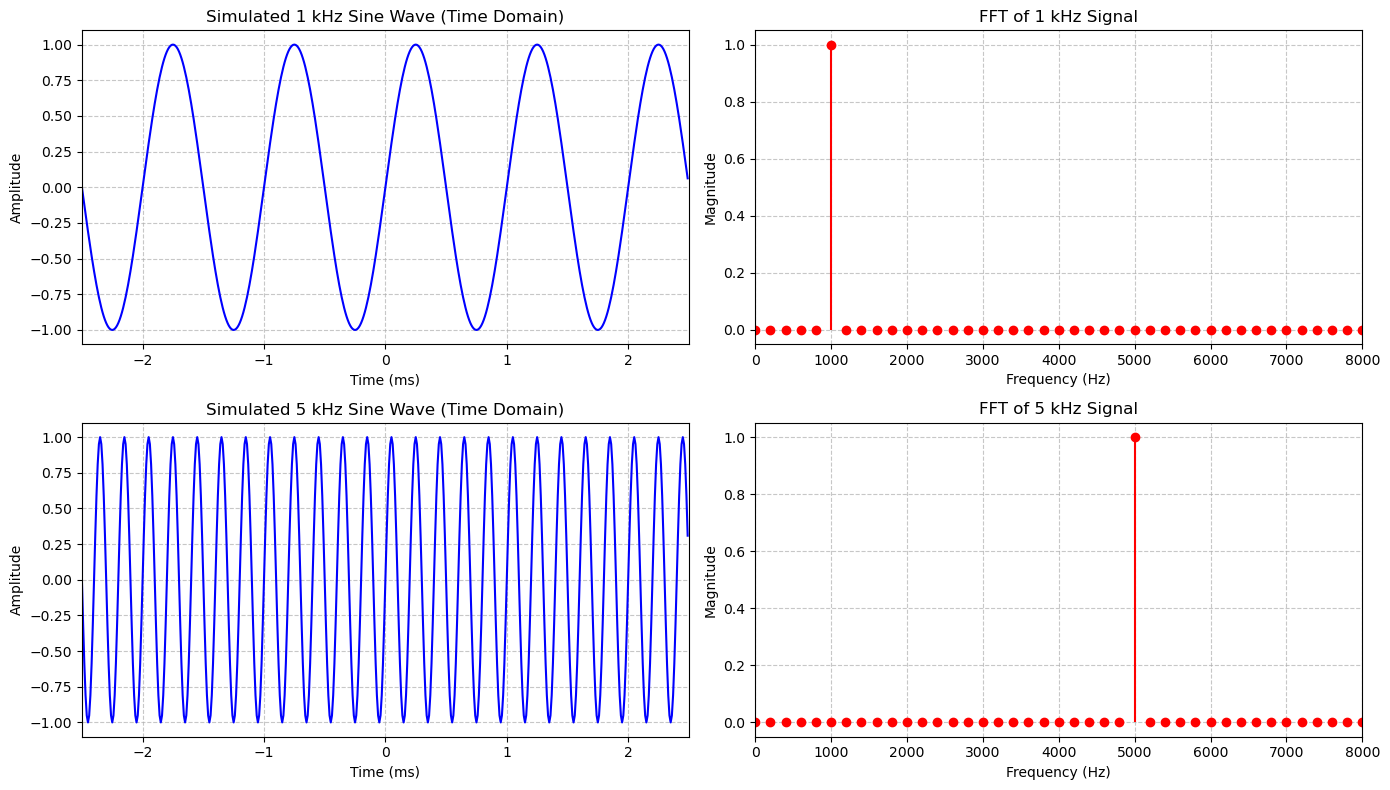

In [81]:
# 1. Setup the time vector (-2.5 ms to +2.5 ms)
fs = 100000  # 100 kHz sampling rate
t = np.linspace(-0.0025, 0.0025, int(0.005 * fs), endpoint=False)

# 2. Generate the simulated sine waves (1 kHz and 5 kHz)
signal_1k = np.sin(2 * np.pi * 1000 * t)
signal_5k = np.sin(2 * np.pi * 5000 * t)

# 3. Calculate the FFTs
N = len(t)
freqs = np.fft.fftfreq(N, d=1/fs)

# Keep only positive frequencies
pos_mask = freqs >= 0
freqs_pos = freqs[pos_mask]

# Calculate magnitudes
mags_1k = (np.abs(np.fft.fft(signal_1k)[pos_mask]) / N) * 2
mags_5k = (np.abs(np.fft.fft(signal_5k)[pos_mask]) / N) * 2

# --- 4. Create the 4 Subplots (2x2 grid) ---
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Subplot [0, 0]: 1 kHz Time Domain
axs[0, 0].plot(t * 1000, signal_1k, color='blue')
axs[0, 0].set_title("Simulated 1 kHz Sine Wave (Time Domain)")
axs[0, 0].set_xlabel("Time (ms)")
axs[0, 0].set_ylabel("Amplitude")
axs[0, 0].grid(True, linestyle='--', alpha=0.7)
axs[0, 0].set_xlim(-2.5, 2.5)

# Subplot [0, 1]: 1 kHz FFT
axs[0, 1].stem(freqs_pos, mags_1k, basefmt=" ", linefmt='red', markerfmt='ro')
axs[0, 1].set_title("FFT of 1 kHz Signal")
axs[0, 1].set_xlabel("Frequency (Hz)")
axs[0, 1].set_ylabel("Magnitude")
axs[0, 1].grid(True, linestyle='--', alpha=0.7)
axs[0, 1].set_xlim(0, 8000) # Setting to 8000 so both 1k and 5k peaks are visible on the same scale

# Subplot [1, 0]: 5 kHz Time Domain
axs[1, 0].plot(t * 1000, signal_5k, color='blue')
axs[1, 0].set_title("Simulated 5 kHz Sine Wave (Time Domain)")
axs[1, 0].set_xlabel("Time (ms)")
axs[1, 0].set_ylabel("Amplitude")
axs[1, 0].grid(True, linestyle='--', alpha=0.7)
axs[1, 0].set_xlim(-2.5, 2.5)

# Subplot [1, 1]: 5 kHz FFT
axs[1, 1].stem(freqs_pos, mags_5k, basefmt=" ", linefmt='red', markerfmt='ro')
axs[1, 1].set_title("FFT of 5 kHz Signal")
axs[1, 1].set_xlabel("Frequency (Hz)")
axs[1, 1].set_ylabel("Magnitude")
axs[1, 1].grid(True, linestyle='--', alpha=0.7)
axs[1, 1].set_xlim(0, 8000)

plt.tight_layout()
plt.show()